# Score Linhas

O objetivo deste notebook é atribuir pontuações de risco para cada linha de ônibus do município do Rio de Janeiro.

## Métrica de pontuação

A métrica atualmente adotada é dada por: $$\frac{\sum_{i} d_i*r_i}{\sum_{i} d_i} $$ onde $d_i$ representa a distância que a linha percorre na cisp i e $r_i$ é o risco daquela cisp. O risco de cada cisp é (por enquanto) dado pela soma do número de ocorrências ocorridas naquela região no ultimo ano.

To-DO: pensar em métrica melhor. talvez levar em conta a tendência de subida ou queda seja importante!

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sklearn

In [85]:
with open("../datasets/dataframe.pkl","rb") as file:
    df = pickle.load(file)
df = df[["cisp","furto_coletivo","roubo_em_coletivo","ano"]]
df["occur_bus"] = df["furto_coletivo"] +df["roubo_em_coletivo"]
df = df[df["ano"]==2024]
df.head()

,cisp,furto_coletivo,roubo_em_coletivo,ano,occur_bus
33889,1,12,4,2024,16
33890,4,19,20,2024,39
33891,5,12,2,2024,14
33892,6,23,17,2024,40
33893,7,0,2,2024,2


In [86]:
#somando ao longo dos 12 meses 
df = df.groupby("cisp")["occur_bus"].sum() / 12
df.columns = ("riscos")
df

cisp
1     19.750000
4     26.916667
5     14.500000
6     35.000000
7      3.083333
9     23.000000
10    27.250000
11     1.333333
12    16.500000
13     6.000000
14     6.416667
15     9.166667
16    51.416667
17    46.416667
18    38.333333
19    26.250000
20    21.000000
21    75.250000
22    21.083333
23    14.416667
24    15.416667
25    34.083333
26    22.083333
27    21.666667
28    13.833333
29    46.250000
30    11.416667
31    14.250000
32    33.666667
33    11.666667
34    21.500000
35    19.000000
36    12.833333
37    12.083333
38    10.750000
39    48.000000
40    10.500000
41    17.333333
42    23.500000
43     5.500000
44    12.250000
48     0.666667
50     1.916667
51     0.000000
52    17.666667
53    13.000000
54    21.750000
55     2.083333
56    18.000000
57     3.750000
58    10.416667
59    27.166667
60    11.833333
61     0.500000
62     4.250000
63     1.250000
64    39.250000
65     0.583333
66     1.000000
67     0.166667
Name: occur_bus, dtype: float64

In [87]:
df.loc[1]

np.float64(19.75)

#### calculando score das linhas

In [88]:
with open("../datasets/linhas_cisps.pkl","rb") as file:
    rotas = pickle.load(file)
rotas.head()

,route_id,shape_id,distancia_por_cisp,route_short_name,route_long_name
0,E2336AAA0A,ab43,"[(40, 1.52), (5, 2.06), (27, 1.91), (1, 0.17),...",2336,Campo Grande - Castelo
1,O0629AAA0A,ue02,"[(21, 2.13), (25, 4.88), (27, 5.54), (38, 1.08...",629,Irajá - Saens Peña
2,O0774AAA0A,i9sp,"[(38, 7.94), (27, 4.65), (29, 4.88), (27, 4.64...",774,Madureira - Jardim América
3,O0112AAA0A,O0112AAA0AVDU03,"[(6, 5.81), (18, 0.05), (15, 4.91), (4, 1.31),...",112,Terminal Gentileza - Alto Gávea
4,O0343AAA0A,j7v9,"[(18, 0.05), (26, 2.32), (1, 1.8), (4, 1.31), ...",343,Jardim Oceânico - Candelária


In [89]:
rotas = rotas.drop_duplicates(subset="route_id")
(rotas[rotas["route_short_name"]=="232"])

,route_id,shape_id,distancia_por_cisp,route_short_name,route_long_name
377,O0232AAA0A,9ptt,"[(5, 2.23), (18, 3.14), (5, 2.24), (1, 1.09), ...",232,Lins de Vasconcelos - Castelo


In [97]:
def calcular_score_ponderado(rota, riscos):
    if not rota:
        return 0
    soma_ponderada = 0
    soma_distancias = 0
    for cisp, distancia in rota:
        if cisp in riscos.index:
            risco = riscos.loc[cisp]
            soma_ponderada += (risco * distancia)
            soma_distancias += distancia
    return soma_ponderada / soma_distancias if soma_distancias > 0 else 0
rotas['score'] = rotas['distancia_por_cisp'].apply(lambda x: calcular_score_ponderado(x, df))

### Vizualizando score de linhas

<Axes: >

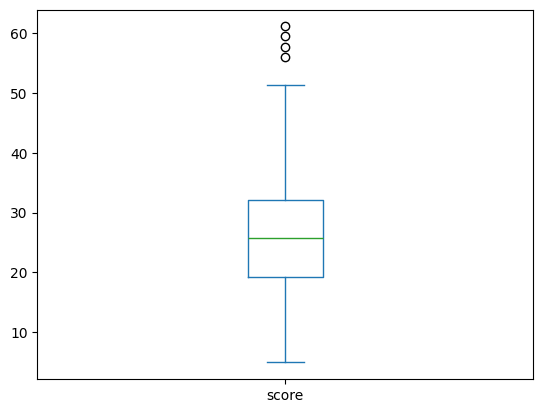

In [91]:
rotas["score"].plot.box()

In [96]:
(rotas[rotas["score"]>=50])

,route_id,shape_id,distancia_por_cisp,route_short_name,route_long_name,score
8,O0805AAP0A,822y,"[(16, 10.98), (16, 9.44)]",SP805,Terminal Alvorada - Passarela da Barra,51.416667
133,O0862AAA0A,m3ov,"[(32, 0.9), (16, 14.31)]",862,Rio das Pedras - Barra da Tijuca,50.366371
143,20000221110,ivlc,"[(16, 6.18), (16, 6.17)]",22,Terminal Alvorada - Terminal Jardim Oceânico,51.416667
302,O0805AAA0A,0piv,"[(16, 14.25), (16, 13.68), (16, 13.63), (16, 1...",805,Terminal Alvorada - Jardim Oceânico,51.416667
323,O0622AAA0A,ydhh,"[(19, 0.88), (22, 3.87), (25, 1.6), (17, 0.83)...",622,Penha - Saens Peña,57.668679
582,20000801110,pxc0,"[(21, 6.66), (22, 1.81), (17, 2.65)]",80,Penha - Terminal Gentileza,59.562050
794,20000901110,w3rb,"[(37, 0.99), (17, 2.65), (21, 6.22)]",90,Terminal Fundão - Terminal Gentileza,61.158384
980,20000EXEC1110,bzfm,"[(21, 6.05), (17, 3.05), (21, 6.09), (4, 0.09)...",ESP01,Galeão - Terminal Gentileza,56.080057
1070,O0335AAV0A,2hp1,"[(17, 4.06), (17, 3.64), (18, 0.05), (21, 6.56...",SV335,Cordovil - Tiradentes,51.306549
1367,O0844AAA0A,O0844AAA0AVDU02,"[(16, 6.57), (16, 6.7)]",844,Jardim Oceânico - Barrinha,51.416667


In [98]:
rotas.to_pickle("../datasets/rotas_riscos.pkl")